**Since the internal cycle counter did not provide a clearly interpretable full signal cycle length, the static signal timing approximation was derived directly from the observed second-by-second signal-state pattern. Consecutive identical signal-state combinations were compressed into phase blocks, and recurring phase blocks were analysed to identify representative phase durations.**

**LSA16 Phase Pattern Extractor - Morning**

In [1]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 5: LSA16 PHASE PATTERN EXTRACTOR
# ============================================================
# Purpose:
# - Read LSA16 signal-state JSON files
# - Select one representative scenario
# - Extract K1, K2, K3, K4 states second by second
# - Compress consecutive identical signal-state combinations
# - Create phase block table for static SUMO approximation
# ============================================================

# ============================================================
# SETTINGS
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA16_6c5e44f1-3aae-4c29-926c-8db5b61da400"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Choose scenario here
SCENARIO_NAME = "weekday_morning"
TARGET_DATE = "2026-03-10"
WINDOW_START = "08:00:00"
WINDOW_END = "09:00:00"

OUT_CSV = OUT_DIR / f"LSA16_phase_blocks_{SCENARIO_NAME}.csv"
OUT_XLSX = OUT_DIR / f"LSA16_phase_blocks_{SCENARIO_NAME}.xlsx"

# Signal group mapping
SIGNAL_GROUPS = {
    "K1": 1,  # South
    "K2": 2,  # West
    "K3": 3,  # North
    "K4": 4,  # East
}

# ============================================================
# PARSE SIGNAL DATA
# ============================================================

rows = []

for json_path in sorted(SIGNAL_DIR.glob("*.json")):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    start_utc = pd.to_datetime(data["start"])

    for value in data.get("values", []):
        timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
        timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

        date_local = str(timestamp_local.date())
        time_local = timestamp_local.time()

        if date_local != TARGET_DATE:
            continue

        start_t = pd.to_datetime(WINDOW_START).time()
        end_t = pd.to_datetime(WINDOW_END).time()

        if not (start_t <= time_local < end_t):
            continue

        sig_states = {
            item["id"]: item["sgState"]
            for item in value.get("sigState", [])
        }

        node_info = value.get("nodes", [{}])[0]

        row = {
            "timestamp_local": timestamp_local,
            "date": date_local,
            "time": time_local,
            "program": node_info.get("program"),
            "stage": node_info.get("stage"),
            "cycCnt": node_info.get("cycCnt"),
            "stgCnt": node_info.get("stgCnt"),
            "stgTran": node_info.get("stgTran"),
        }

        for group_name, signal_id in SIGNAL_GROUPS.items():
            row[group_name] = sig_states.get(signal_id)

        rows.append(row)

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No signal data found for selected date and time window.")

df = df.sort_values("timestamp_local").reset_index(drop=True)

# Pattern based on K1-K4 states
df["pattern"] = (
    df["K1"].astype(str) + "-" +
    df["K2"].astype(str) + "-" +
    df["K3"].astype(str) + "-" +
    df["K4"].astype(str)
)

# ============================================================
# COMPRESS CONSECUTIVE IDENTICAL PATTERNS INTO PHASE BLOCKS
# ============================================================

df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

phase_blocks = (
    df.groupby("block_id")
    .agg(
        start_time=("timestamp_local", "first"),
        end_time=("timestamp_local", "last"),
        date=("date", "first"),
        K1=("K1", "first"),
        K2=("K2", "first"),
        K3=("K3", "first"),
        K4=("K4", "first"),
        pattern=("pattern", "first"),
        stage=("stage", "first"),
        program=("program", "first"),
        n_seconds=("pattern", "count"),
    )
    .reset_index()
)

# Since data is secondwise, duration is number of rows
phase_blocks["duration_s"] = phase_blocks["n_seconds"]

# Convert timezone-aware timestamps to string for Excel
phase_blocks["start_time"] = phase_blocks["start_time"].astype(str)
phase_blocks["end_time"] = phase_blocks["end_time"].astype(str)

# ============================================================
# PATTERN SUMMARY
# ============================================================

pattern_summary = (
    phase_blocks
    .groupby(["pattern", "K1", "K2", "K3", "K4"])
    .agg(
        occurrences=("block_id", "count"),
        total_duration_s=("duration_s", "sum"),
        mean_duration_s=("duration_s", "mean"),
        median_duration_s=("duration_s", "median"),
        min_duration_s=("duration_s", "min"),
        max_duration_s=("duration_s", "max"),
    )
    .reset_index()
    .sort_values("total_duration_s", ascending=False)
)

# ============================================================
# SAVE OUTPUTS
# ============================================================

phase_blocks.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    phase_blocks.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    df_excel = df.copy()
    df_excel["timestamp_local"] = df_excel["timestamp_local"].astype(str)
    df_excel.to_excel(writer, sheet_name="Secondwise_K1_K4", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nTop recurring patterns:")
print(pattern_summary.head(20))

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\LSA16_phase_blocks_weekday_morning.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\LSA16_phase_blocks_weekday_morning.xlsx

Top recurring patterns:
   pattern  K1  K2  K3  K4  occurrences  total_duration_s  mean_duration_s  \
4  2-4-2-4   2   4   2   4           40              1069        26.725000   
7  4-2-4-2   4   2   4   2           40               901        22.525000   
2  2-2-2-4   2   2   2   4           41               870        21.219512   
0  2-2-2-2   2   2   2   2           80               320         4.000000   
1  2-2-2-3   2   2   2   3           40               120         3.000000   
3  2-3-2-4   2   3   2   4           40               120         3.000000   
6  3-2-3-2   3   2   3   2           40               120         3.000000   
5  2-5-2-5   2   5   2   5           40                40         1.000000   
8  5-2-5-2   5   2 

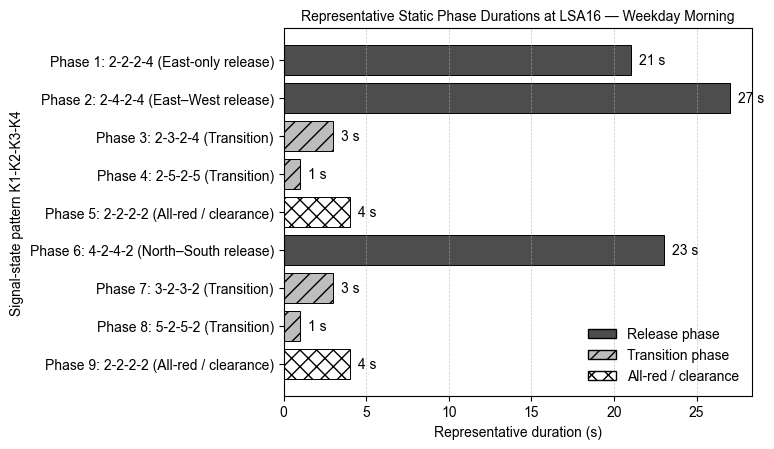

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekday_morning_accessible.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekday_morning_accessible.svg

Representative static phase table:
   phase  pattern  phase_type          description  representative_duration_s
0      1  2-2-2-4     Release    East-only release                         21
1      2  2-4-2-4     Release    East–West release                         27
2      3  2-3-2-4  Transition           Transition                          3
3      4  2-5-2-5  Transition           Transition                          1
4      5  2-2-2-2   Clearance  All-red / clearance                          4
5      6  4-2-4-2     Release  North–South release                         23
6      7  3-2-3-2  Transition           Transition                          3
7      8  5-2-5-2  Transition  

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODE 5B: LSA16 REPRESENTATIVE PHASE DURATION FIGURE
# ============================================================
# Purpose:
# - Read LSA16 phase block output
# - Create a thesis-style horizontal bar chart
# - Distinguish release, transition, and clearance phases
# - Avoid red/green color dependency
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation"
)

IN_XLSX = BASE_DIR / "LSA16_phase_blocks_weekday_morning.xlsx"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "LSA16_representative_phase_durations_weekday_morning_accessible.png"
OUT_SVG = OUT_DIR / "LSA16_representative_phase_durations_weekday_morning_accessible.svg"

# ============================================================
# LOAD DATA
# ============================================================

pattern_summary = pd.read_excel(IN_XLSX, sheet_name="Pattern_Summary")

PHASE_SEQUENCE = [
    "2-2-2-4",
    "2-4-2-4",
    "2-3-2-4",
    "2-5-2-5",
    "2-2-2-2",
    "4-2-4-2",
    "3-2-3-2",
    "5-2-5-2",
    "2-2-2-2",
]

# Because 2-2-2-2 occurs twice in the representative cycle,
# we create the representative table manually from the summary values.

duration_lookup = {
    row["pattern"]: int(round(row["mean_duration_s"]))
    for _, row in pattern_summary.iterrows()
}

representative_rows = [
    {"phase": 1, "pattern": "2-2-2-4", "phase_type": "Release", "description": "East-only release"},
    {"phase": 2, "pattern": "2-4-2-4", "phase_type": "Release", "description": "East–West release"},
    {"phase": 3, "pattern": "2-3-2-4", "phase_type": "Transition", "description": "Transition"},
    {"phase": 4, "pattern": "2-5-2-5", "phase_type": "Transition", "description": "Transition"},
    {"phase": 5, "pattern": "2-2-2-2", "phase_type": "Clearance", "description": "All-red / clearance"},
    {"phase": 6, "pattern": "4-2-4-2", "phase_type": "Release", "description": "North–South release"},
    {"phase": 7, "pattern": "3-2-3-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 8, "pattern": "5-2-5-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 9, "pattern": "2-2-2-2", "phase_type": "Clearance", "description": "All-red / clearance"},
]

df = pd.DataFrame(representative_rows)
df["representative_duration_s"] = df["pattern"].map(duration_lookup)

# ============================================================
# ACCESSIBLE STYLE
# ============================================================

STYLE = {
    "Release": {
        "color": "#4D4D4D",
        "hatch": "",
        "label": "Release phase"
    },
    "Transition": {
        "color": "#BDBDBD",
        "hatch": "//",
        "label": "Transition phase"
    },
    "Clearance": {
        "color": "#FFFFFF",
        "hatch": "xx",
        "label": "All-red / clearance"
    },
}

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(7.8, 4.6))

y_labels = [
    f"Phase {row.phase}: {row.pattern} ({row.description})"
    for _, row in df.iterrows()
]

bars = []

for i, row in df.iterrows():
    style = STYLE[row["phase_type"]]

    bar = ax.barh(
        y_labels[i],
        row["representative_duration_s"],
        color=style["color"],
        edgecolor="black",
        linewidth=0.7,
        hatch=style["hatch"]
    )

    bars.append(bar)

ax.set_title("Representative Static Phase Durations at LSA16 — Weekday Morning")
ax.set_xlabel("Representative duration (s)")
ax.set_ylabel("Signal-state pattern K1-K2-K3-K4")
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

for i, row in df.iterrows():
    ax.text(
        row["representative_duration_s"] + 0.5,
        i,
        f"{row['representative_duration_s']} s",
        va="center"
    )

# Reverse order so Phase 1 appears at the top
ax.invert_yaxis()

# Custom legend
legend_handles = []
legend_labels = []

for phase_type, style in STYLE.items():
    handle = plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor=style["color"],
        edgecolor="black",
        hatch=style["hatch"]
    )
    legend_handles.append(handle)
    legend_labels.append(style["label"])

ax.legend(
    legend_handles,
    legend_labels,
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_SVG, bbox_inches="tight")
plt.show()

print("Saved:")
print(OUT_PNG)
print(OUT_SVG)

print("\nRepresentative static phase table:")
print(df[[
    "phase",
    "pattern",
    "phase_type",
    "description",
    "representative_duration_s"
]])

print("\nApproximate representative cycle length:")
print(df["representative_duration_s"].sum(), "seconds")

In [5]:
from pathlib import Path
import pandas as pd
from xml.dom import minidom
import xml.etree.ElementTree as ET

# ============================================================
# CODE 6: LSA16 STATIC SUMO TLS PROGRAM GENERATOR
# ============================================================
# Purpose:
# - Read representative phase pattern durations
# - Convert K1-K2-K3-K4 signal-state patterns into SUMO TLS states
# - Use NetEdit TLS link index mapping
# - Create a static SUMO additional file for LSA16
# ============================================================

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation"
)

IN_XLSX = BASE_DIR / "LSA16_phase_blocks_weekday_morning.xlsx"

OUT_XML = BASE_DIR / "LSA16_static_tls_weekday_morning.add.xml"
OUT_PHASE_TABLE_CSV = BASE_DIR / "LSA16_static_tls_weekday_morning_phase_table.csv"

# IMPORTANT:
# Replace this with the exact SUMO TLS id from NetEdit if different.
TLS_ID = "tls_9873"

PROGRAM_ID = "derived_weekday_morning"

# ============================================================
# SUMO LINK INDEX TO SIGNAL GROUP MAPPING
# ============================================================
# SUMO TLS state string order:
#
# index 0  -> East right/straight   -> K4
# index 1  -> East right/straight   -> K4
# index 2  -> East left turn        -> K4
# index 3  -> South right turn      -> K1
# index 4  -> South straight        -> K1
# index 5  -> South straight        -> K1
# index 6  -> West right turn       -> K7, permissive flashing/yield movement
# index 7  -> West straight         -> K2
# index 8  -> West left turn        -> K2
# index 9  -> North movement        -> K3
# index 10 -> North straight        -> K3
#
# K7 is treated as constant lowercase "g" because it is a permissive/yield right-turn.
# ============================================================

LINK_INDEX_TO_GROUP = {
    0: "K4",
    1: "K4",
    2: "K4",
    3: "K1",
    4: "K1",
    5: "K1",
    6: "K7",
    7: "K2",
    8: "K2",
    9: "K3",
    10: "K3",
}

# ============================================================
# SIGNAL STATE TO SUMO TLS CHARACTER
# ============================================================

def sgstate_to_sumo_char(sg_state):
    """
    Converts SI PL sgState to SUMO TLS character.

    4 -> G : protected green / release
    3,5 -> y : transition / yellow-like state
    2 -> r : red / blocked
    """
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"


def pattern_to_sumo_state(pattern):
    """
    Converts pattern like '2-4-2-4' for K1-K2-K3-K4
    into SUMO TLS state string according to LINK_INDEX_TO_GROUP.
    """
    k1, k2, k3, k4 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),

        # West right turn, permissive/yield movement
        "K7": "g",
    }

    state_chars = []

    for idx in sorted(LINK_INDEX_TO_GROUP.keys()):
        group = LINK_INDEX_TO_GROUP[idx]
        state_chars.append(group_state[group])

    return "".join(state_chars)

# ============================================================
# LOAD REPRESENTATIVE PATTERN SUMMARY
# ============================================================

pattern_summary = pd.read_excel(IN_XLSX, sheet_name="Pattern_Summary")

duration_lookup = {
    row["pattern"]: int(round(row["mean_duration_s"]))
    for _, row in pattern_summary.iterrows()
}

# ============================================================
# REPRESENTATIVE PHASE SEQUENCE
# ============================================================
# Based on weekday morning recurring signal-state structure.
# 2-2-2-2 appears twice as clearance.
# ============================================================

representative_phases = [
    {
        "phase": 1,
        "pattern": "2-2-2-4",
        "description": "East-only release",
    },
    {
        "phase": 2,
        "pattern": "2-4-2-4",
        "description": "East-West release",
    },
    {
        "phase": 3,
        "pattern": "2-3-2-4",
        "description": "Transition",
    },
    {
        "phase": 4,
        "pattern": "2-5-2-5",
        "description": "Transition",
    },
    {
        "phase": 5,
        "pattern": "2-2-2-2",
        "description": "All-red / clearance",
    },
    {
        "phase": 6,
        "pattern": "4-2-4-2",
        "description": "North-South release",
    },
    {
        "phase": 7,
        "pattern": "3-2-3-2",
        "description": "Transition",
    },
    {
        "phase": 8,
        "pattern": "5-2-5-2",
        "description": "Transition",
    },
    {
        "phase": 9,
        "pattern": "2-2-2-2",
        "description": "All-red / clearance",
    },
]

phase_rows = []

for phase in representative_phases:
    pattern = phase["pattern"]

    if pattern not in duration_lookup:
        raise ValueError(f"Pattern {pattern} not found in Pattern_Summary.")

    duration = duration_lookup[pattern]
    sumo_state = pattern_to_sumo_state(pattern)

    k1, k2, k3, k4 = [int(x) for x in pattern.split("-")]

    phase_rows.append({
        "phase": phase["phase"],
        "pattern_K1_K2_K3_K4": pattern,
        "K1": k1,
        "K2": k2,
        "K3": k3,
        "K4": k4,
        "K7": "permissive_g",
        "duration_s": duration,
        "sumo_state": sumo_state,
        "description": phase["description"],
    })

phase_table = pd.DataFrame(phase_rows)

# ============================================================
# CREATE SUMO TLS XML
# ============================================================

additional = ET.Element("additional")

tl_logic = ET.SubElement(
    additional,
    "tlLogic",
    {
        "id": TLS_ID,
        "type": "static",
        "programID": PROGRAM_ID,
        "offset": "0",
    }
)

for _, row in phase_table.iterrows():
    ET.SubElement(
        tl_logic,
        "phase",
        {
            "duration": str(int(row["duration_s"])),
            "state": row["sumo_state"],
        }
    )

# Pretty print XML
rough_string = ET.tostring(additional, encoding="utf-8")
parsed = minidom.parseString(rough_string)
pretty_xml = parsed.toprettyxml(indent="    ")

with open(OUT_XML, "w", encoding="utf-8") as f:
    f.write(pretty_xml)

phase_table.to_csv(OUT_PHASE_TABLE_CSV, index=False, encoding="utf-8-sig")

# ============================================================
# PRINT RESULTS
# ============================================================

print("Saved SUMO TLS additional file:")
print(OUT_XML)

print("\nSaved phase table:")
print(OUT_PHASE_TABLE_CSV)

print("\nGenerated static phase table:")
print(phase_table)

print("\nSUMO state string length:")
print(len(phase_table.iloc[0]["sumo_state"]))

print("\nApproximate static cycle length:")
print(phase_table["duration_s"].sum(), "seconds")

Saved SUMO TLS additional file:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\LSA16_static_tls_weekday_morning.add.xml

Saved phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\LSA16_static_tls_weekday_morning_phase_table.csv

Generated static phase table:
   phase pattern_K1_K2_K3_K4  K1  K2  K3  K4            K7  duration_s  \
0      1             2-2-2-4   2   2   2   4  permissive_g          21   
1      2             2-4-2-4   2   4   2   4  permissive_g          27   
2      3             2-3-2-4   2   3   2   4  permissive_g           3   
3      4             2-5-2-5   2   5   2   5  permissive_g           1   
4      5             2-2-2-2   2   2   2   2  permissive_g           4   
5      6             4-2-4-2   4   2   4   2  permissive_g          23   
6      7             3-2-3-2   3   2   3   2  permissive_g           3   
7      8             5-2-5-2   5   2   5   2  permissive_g           1   
8      9   

extract phase patterns for all 4 representative scenarios

create one Excel with phase blocks + summaries

create one static TLS XML per scenario

create one phase-duration graph per scenario


Found signal JSON files: 320
Parsed rows: 3359711

Processing scenario: weekday_morning

Available patterns:
   pattern  occurrences  total_duration_s  mean_duration_s
4  2-4-2-4           40              1069        26.725000
7  4-2-4-2           40               901        22.525000
2  2-2-2-4           41               870        21.219512
0  2-2-2-2           80               320         4.000000
1  2-2-2-3           40               120         3.000000
3  2-3-2-4           40               120         3.000000
6  3-2-3-2           40               120         3.000000
5  2-5-2-5           40                40         1.000000
8  5-2-5-2           40                40         1.000000


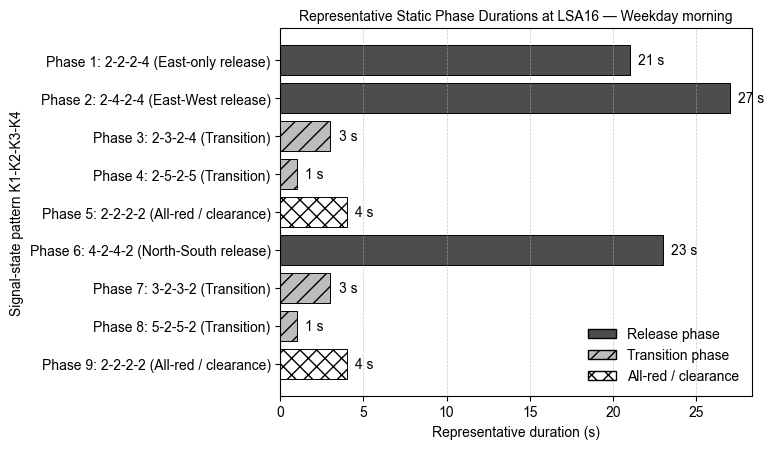

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekday_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekday_morning.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\static_tls_programs\LSA16_static_tls_weekday_morning.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\static_tls_programs\LSA16_static_tls_weekday_morning_phase_table.csv
Approximate static cycle length: 87 s

Processing scenario: weekday_evening

Available patterns:
   pattern  occurrences  total_duration_s  mean_duration_s
2  2-2-2-4           41               999        24.365854
4  2-4-2-4           40               949        23.725000
7  4-2-4-2           40               893        22.325000
0  2-2-2-2           80               320     

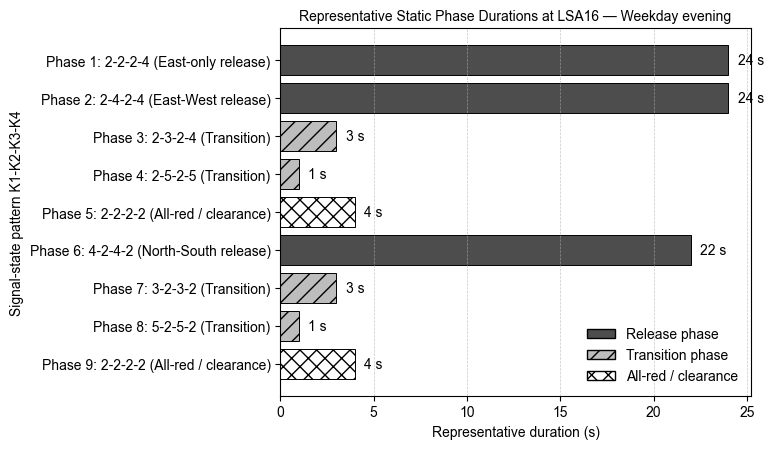

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekday_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekday_evening.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\static_tls_programs\LSA16_static_tls_weekday_evening.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\static_tls_programs\LSA16_static_tls_weekday_evening_phase_table.csv
Approximate static cycle length: 86 s

Processing scenario: weekend_morning

Available patterns:
   pattern  occurrences  total_duration_s  mean_duration_s
7  4-2-4-2           41              1327        32.365854
4  2-4-2-4           40               999        24.975000
2  2-2-2-4           40               510        12.750000
0  2-2-2-2           81               323     

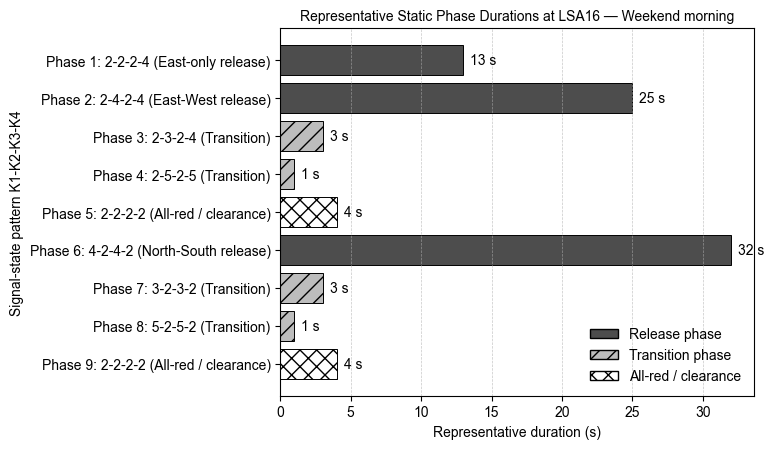

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekend_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekend_morning.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\static_tls_programs\LSA16_static_tls_weekend_morning.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\static_tls_programs\LSA16_static_tls_weekend_morning_phase_table.csv
Approximate static cycle length: 86 s

Processing scenario: weekend_evening

Available patterns:
   pattern  occurrences  total_duration_s  mean_duration_s
7  4-2-4-2           40              1127        28.175000
4  2-4-2-4           40              1008        25.200000
2  2-2-2-4           41               706        17.219512
0  2-2-2-2           80               320     

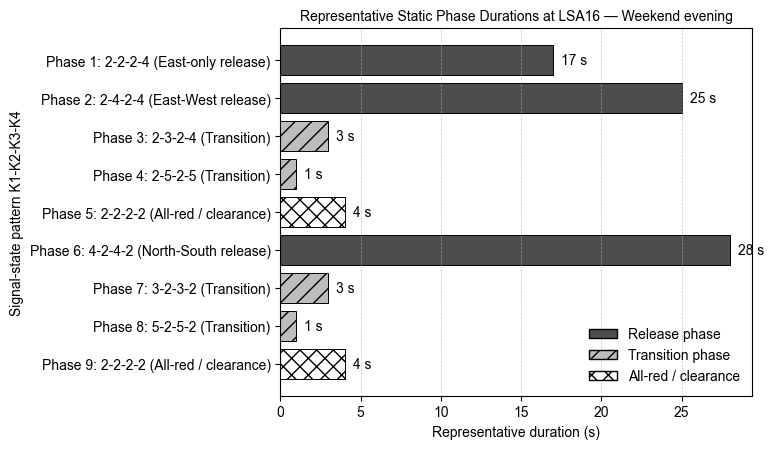

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekend_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_weekend_evening.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\static_tls_programs\LSA16_static_tls_weekend_evening.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\static_tls_programs\LSA16_static_tls_weekend_evening_phase_table.csv
Approximate static cycle length: 86 s

DONE
Saved combined Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\LSA16_all_scenarios_phase_patterns_and_static_tls.xlsx

Saved TLS XML files in:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\static_tls_programs

Saved figures in:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\sat

In [7]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from xml.dom import minidom

# ============================================================
# CODE 7: LSA16 STATIC TLS PROGRAMS + PHASE GRAPHS FOR ALL SCENARIOS
# ============================================================
# Purpose:
# - Extract phase patterns for all representative scenarios
# - Build representative static phase tables
# - Generate SUMO static TLS additional files
# - Create phase duration figures for each scenario
# ============================================================

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# SETTINGS
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA16_6c5e44f1-3aae-4c29-926c-8db5b61da400"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TLS_DIR = OUT_DIR / "static_tls_programs"
TLS_DIR.mkdir(parents=True, exist_ok=True)

TLS_ID = "tls_9873"   # NetEdit'teki gerçek TLS id farklıysa burayı değiştir

SCENARIOS = {
    "weekday_morning": {
        "date": "2026-03-10",
        "start": "08:00:00",
        "end": "09:00:00",
        "label": "Weekday morning",
    },
    "weekday_evening": {
        "date": "2026-03-23",
        "start": "16:00:00",
        "end": "17:00:00",
        "label": "Weekday evening",
    },
    "weekend_morning": {
        "date": "2026-03-14",
        "start": "08:00:00",
        "end": "09:00:00",
        "label": "Weekend morning",
    },
    "weekend_evening": {
        "date": "2026-03-22",
        "start": "16:00:00",
        "end": "17:00:00",
        "label": "Weekend evening",
    },
}

SIGNAL_GROUPS = {
    "K1": 1,  # South
    "K2": 2,  # West
    "K3": 3,  # North
    "K4": 4,  # East
}

# ============================================================
# SUMO LINK INDEX MAPPING
# ============================================================

LINK_INDEX_TO_GROUP = {
    0: "K4",   # East right + straight
    1: "K4",   # East right + straight
    2: "K4",   # East left
    3: "K1",   # South right
    4: "K1",   # South straight
    5: "K1",   # South straight
    6: "K7",   # West right, permissive/yield
    7: "K2",   # West straight
    8: "K2",   # West left
    9: "K3",   # North right
    10: "K3",  # North straight
}

# Representative sequence from the observed recurring LSA16 pattern
REPRESENTATIVE_PHASE_SEQUENCE = [
    {"phase": 1, "pattern": "2-2-2-4", "phase_type": "Release", "description": "East-only release"},
    {"phase": 2, "pattern": "2-4-2-4", "phase_type": "Release", "description": "East-West release"},
    {"phase": 3, "pattern": "2-3-2-4", "phase_type": "Transition", "description": "Transition"},
    {"phase": 4, "pattern": "2-5-2-5", "phase_type": "Transition", "description": "Transition"},
    {"phase": 5, "pattern": "2-2-2-2", "phase_type": "Clearance", "description": "All-red / clearance"},
    {"phase": 6, "pattern": "4-2-4-2", "phase_type": "Release", "description": "North-South release"},
    {"phase": 7, "pattern": "3-2-3-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 8, "pattern": "5-2-5-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 9, "pattern": "2-2-2-2", "phase_type": "Clearance", "description": "All-red / clearance"},
]

STYLE = {
    "Release": {
        "color": "#4D4D4D",
        "hatch": "",
        "label": "Release phase",
    },
    "Transition": {
        "color": "#BDBDBD",
        "hatch": "//",
        "label": "Transition phase",
    },
    "Clearance": {
        "color": "#FFFFFF",
        "hatch": "xx",
        "label": "All-red / clearance",
    },
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def sgstate_to_sumo_char(sg_state):
    """
    SI PL sgState -> SUMO state character

    4     -> G : protected green / release
    3, 5  -> y : transition / yellow-like state
    2     -> r : red / blocked
    """
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"


def pattern_to_sumo_state(pattern):
    """
    Converts K1-K2-K3-K4 pattern into SUMO TLS state string.
    Example:
    pattern = "2-4-2-4"
    """
    k1, k2, k3, k4 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),

        # West right turn, permissive/yield movement
        "K7": "g",
    }

    return "".join(
        group_state[LINK_INDEX_TO_GROUP[idx]]
        for idx in sorted(LINK_INDEX_TO_GROUP.keys())
    )


def save_sumo_tls_xml(phase_table, out_xml, program_id):
    additional = ET.Element("additional")

    tl_logic = ET.SubElement(
        additional,
        "tlLogic",
        {
            "id": TLS_ID,
            "type": "static",
            "programID": program_id,
            "offset": "0",
        }
    )

    for _, row in phase_table.iterrows():
        ET.SubElement(
            tl_logic,
            "phase",
            {
                "duration": str(int(row["duration_s"])),
                "state": row["sumo_state"],
            }
        )

    rough_string = ET.tostring(additional, encoding="utf-8")
    parsed = minidom.parseString(rough_string)
    pretty_xml = parsed.toprettyxml(indent="    ")

    with open(out_xml, "w", encoding="utf-8") as f:
        f.write(pretty_xml)


def plot_phase_durations(phase_table, scenario_name, scenario_label):
    out_png = FIG_DIR / f"LSA16_representative_phase_durations_{scenario_name}.png"
    out_svg = FIG_DIR / f"LSA16_representative_phase_durations_{scenario_name}.svg"

    fig, ax = plt.subplots(figsize=(7.8, 4.6))

    y_labels = [
        f"Phase {row.phase}: {row.pattern_K1_K2_K3_K4} ({row.description})"
        for _, row in phase_table.iterrows()
    ]

    for i, row in phase_table.iterrows():
        style = STYLE[row["phase_type"]]

        ax.barh(
            y_labels[i],
            row["duration_s"],
            color=style["color"],
            edgecolor="black",
            linewidth=0.7,
            hatch=style["hatch"]
        )

        ax.text(
            row["duration_s"] + 0.5,
            i,
            f"{int(row['duration_s'])} s",
            va="center"
        )

    ax.set_title(f"Representative Static Phase Durations at LSA16 — {scenario_label}")
    ax.set_xlabel("Representative duration (s)")
    ax.set_ylabel("Signal-state pattern K1-K2-K3-K4")
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.invert_yaxis()

    legend_handles = []
    legend_labels = []

    for _, style in STYLE.items():
        handle = plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=style["color"],
            edgecolor="black",
            hatch=style["hatch"]
        )
        legend_handles.append(handle)
        legend_labels.append(style["label"])

    ax.legend(
        legend_handles,
        legend_labels,
        frameon=False,
        loc="lower right"
    )

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved figure:")
    print(out_png)
    print(out_svg)


# ============================================================
# PARSE ALL SIGNAL FILES ONCE
# ============================================================

rows = []

json_files = sorted(SIGNAL_DIR.glob("*.json"))
print(f"Found signal JSON files: {len(json_files)}")

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        start_utc = pd.to_datetime(data["start"])

        for value in data.get("values", []):
            timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
            timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

            sig_states = {
                item["id"]: item["sgState"]
                for item in value.get("sigState", [])
            }

            node_info = value.get("nodes", [{}])[0]

            row = {
                "timestamp_local": timestamp_local,
                "date": str(timestamp_local.date()),
                "time": timestamp_local.time(),
                "program": node_info.get("program"),
                "stage": node_info.get("stage"),
                "cycCnt": node_info.get("cycCnt"),
                "stgCnt": node_info.get("stgCnt"),
                "stgTran": node_info.get("stgTran"),
            }

            for group_name, signal_id in SIGNAL_GROUPS.items():
                row[group_name] = sig_states.get(signal_id)

            rows.append(row)

    except Exception as e:
        print(f"Could not parse {json_path.name}: {e}")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise ValueError("No signal data parsed.")

print("Parsed rows:", len(df_all))

# ============================================================
# PROCESS EACH SCENARIO
# ============================================================

all_phase_blocks = []
all_pattern_summaries = []
all_static_phase_tables = []

for scenario_name, scenario in SCENARIOS.items():

    print("\n" + "=" * 70)
    print(f"Processing scenario: {scenario_name}")
    print("=" * 70)

    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    df = df_all[
        (df_all["date"] == scenario["date"]) &
        (df_all["time"] >= start_t) &
        (df_all["time"] < end_t)
    ].copy()

    if df.empty:
        print(f"No data found for {scenario_name}. Skipping.")
        continue

    df = df.sort_values("timestamp_local").reset_index(drop=True)

    # IMPORTANT FIX:
    # Convert K1-K4 to clean integer values before creating patterns.
    # Without this, patterns may become "2.0-2.0-2.0-4.0",
    # which does not match "2-2-2-4".
    for col in ["K1", "K2", "K3", "K4"]:
        df[col] = df[col].astype(int)

    df["pattern"] = (
        df["K1"].astype(str) + "-" +
        df["K2"].astype(str) + "-" +
        df["K3"].astype(str) + "-" +
        df["K4"].astype(str)
    )

    df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

    phase_blocks = (
        df.groupby("block_id")
        .agg(
            start_time=("timestamp_local", "first"),
            end_time=("timestamp_local", "last"),
            date=("date", "first"),
            K1=("K1", "first"),
            K2=("K2", "first"),
            K3=("K3", "first"),
            K4=("K4", "first"),
            pattern=("pattern", "first"),
            stage=("stage", "first"),
            program=("program", "first"),
            n_seconds=("pattern", "count"),
        )
        .reset_index()
    )

    phase_blocks["duration_s"] = phase_blocks["n_seconds"]
    phase_blocks["scenario"] = scenario_name
    phase_blocks["window_start"] = scenario["start"]
    phase_blocks["window_end"] = scenario["end"]

    pattern_summary = (
        phase_blocks
        .groupby(["scenario", "pattern", "K1", "K2", "K3", "K4"])
        .agg(
            occurrences=("block_id", "count"),
            total_duration_s=("duration_s", "sum"),
            mean_duration_s=("duration_s", "mean"),
            median_duration_s=("duration_s", "median"),
            min_duration_s=("duration_s", "min"),
            max_duration_s=("duration_s", "max"),
        )
        .reset_index()
        .sort_values("total_duration_s", ascending=False)
    )

    duration_lookup = {
        str(row["pattern"]): int(round(row["mean_duration_s"]))
        for _, row in pattern_summary.iterrows()
    }

    print("\nAvailable patterns:")
    print(pattern_summary[["pattern", "occurrences", "total_duration_s", "mean_duration_s"]].head(20))

    static_rows = []

    for phase in REPRESENTATIVE_PHASE_SEQUENCE:
        pattern = phase["pattern"]

        # IMPORTANT FIX:
        # Do not use fallback 1 s. If a pattern is missing, stop the code.
        if pattern not in duration_lookup:
            raise ValueError(
                f"Pattern {pattern} not found for {scenario_name}. "
                f"Available patterns are: {list(duration_lookup.keys())}"
            )

        duration = duration_lookup[pattern]
        sumo_state = pattern_to_sumo_state(pattern)
        k1, k2, k3, k4 = [int(x) for x in pattern.split("-")]

        static_rows.append({
            "scenario": scenario_name,
            "phase": phase["phase"],
            "pattern_K1_K2_K3_K4": pattern,
            "K1": k1,
            "K2": k2,
            "K3": k3,
            "K4": k4,
            "K7": "permissive_g",
            "duration_s": duration,
            "sumo_state": sumo_state,
            "phase_type": phase["phase_type"],
            "description": phase["description"],
        })

    static_phase_table = pd.DataFrame(static_rows)

    program_id = f"derived_{scenario_name}"

    out_xml = TLS_DIR / f"LSA16_static_tls_{scenario_name}.add.xml"
    out_csv = TLS_DIR / f"LSA16_static_tls_{scenario_name}_phase_table.csv"

    save_sumo_tls_xml(static_phase_table, out_xml, program_id)
    static_phase_table.to_csv(out_csv, index=False, encoding="utf-8-sig")

    plot_phase_durations(static_phase_table, scenario_name, scenario["label"])

    print("\nSaved SUMO TLS XML:")
    print(out_xml)

    print("Saved static phase table:")
    print(out_csv)

    print("Approximate static cycle length:", static_phase_table["duration_s"].sum(), "s")

    phase_blocks_excel = phase_blocks.copy()
    phase_blocks_excel["start_time"] = phase_blocks_excel["start_time"].astype(str)
    phase_blocks_excel["end_time"] = phase_blocks_excel["end_time"].astype(str)

    all_phase_blocks.append(phase_blocks_excel)
    all_pattern_summaries.append(pattern_summary)
    all_static_phase_tables.append(static_phase_table)

# ============================================================
# SAVE COMBINED EXCEL
# ============================================================

combined_phase_blocks = pd.concat(all_phase_blocks, ignore_index=True)
combined_pattern_summary = pd.concat(all_pattern_summaries, ignore_index=True)
combined_static_phase_table = pd.concat(all_static_phase_tables, ignore_index=True)

OUT_XLSX = OUT_DIR / "LSA16_all_scenarios_phase_patterns_and_static_tls.xlsx"

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    combined_phase_blocks.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    combined_pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    combined_static_phase_table.to_excel(writer, sheet_name="Static_TLS_Phase_Table", index=False)

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

print("Saved combined Excel:")
print(OUT_XLSX)

print("\nSaved TLS XML files in:")
print(TLS_DIR)

print("\nSaved figures in:")
print(FIG_DIR)

print("\nStatic phase table preview:")
print(combined_static_phase_table)

print("\nCycle lengths by scenario:")
print(
    combined_static_phase_table
    .groupby("scenario")["duration_s"]
    .sum()
    .reset_index(name="approx_static_cycle_length_s")
)

For LSA16, the representative static signal plans were derived by compressing the observed second-by-second signal-state combinations into recurring phase blocks. The resulting static cycle lengths were highly consistent across the selected representative scenarios, ranging between 86 and 87 seconds. This indicates that the extracted phase structure provides a stable approximation of the real-world signal control logic for the analysed periods.

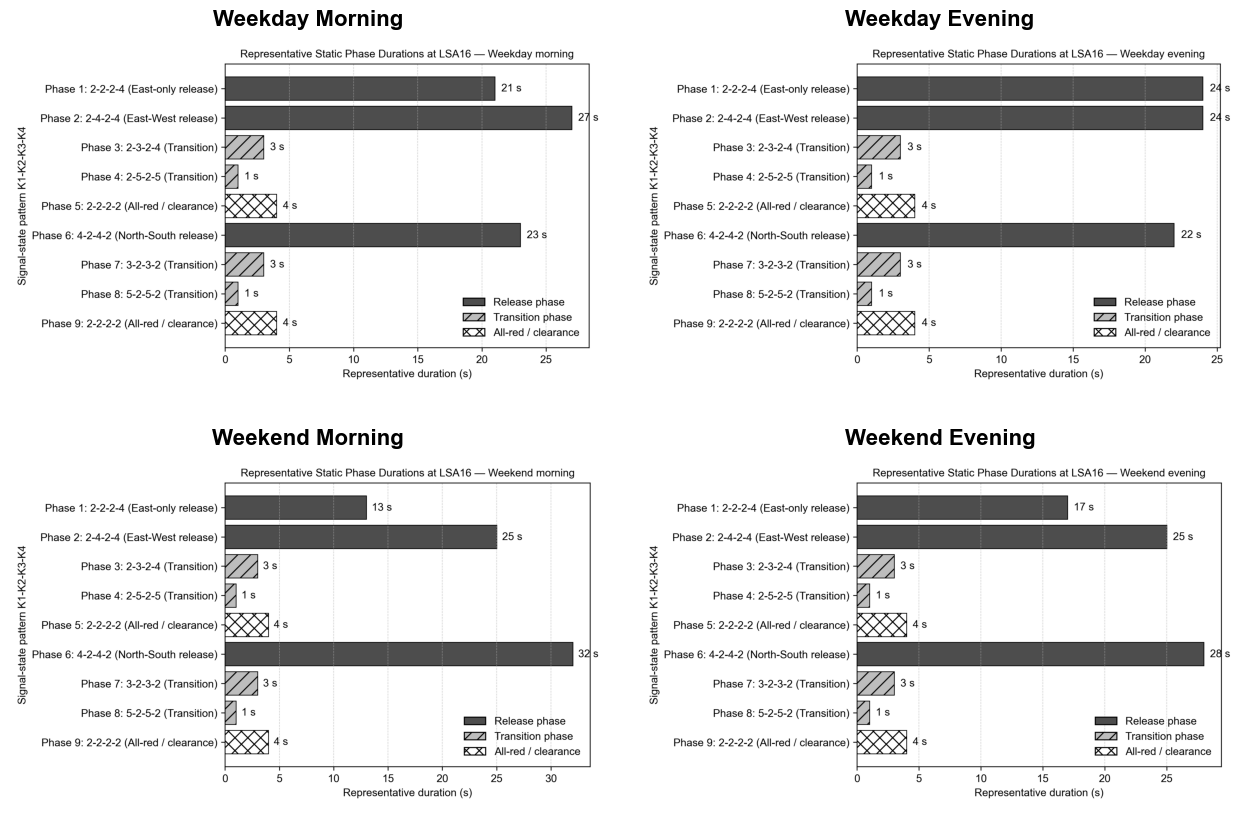

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures\LSA16_representative_phase_durations_combined.png


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ============================================================
# THESIS STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\figures"
)

scenarios = [
    ("weekday_morning", "Weekday Morning"),
    ("weekday_evening", "Weekday Evening"),
    ("weekend_morning", "Weekend Morning"),
    ("weekend_evening", "Weekend Evening"),
]

prefix = "LSA16_representative_phase_durations"

out_file = BASE_DIR / "LSA16_representative_phase_durations_combined.png"

# ============================================================
# CREATE COMBINED FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (scenario, title) in zip(axes, scenarios):

    img_path = BASE_DIR / f"{prefix}_{scenario}.png"

    if not img_path.exists():
        raise FileNotFoundError(f"File not found: {img_path}")

    img = mpimg.imread(img_path)

    ax.imshow(img)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")

plt.tight_layout(pad=2.0)

plt.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_file}")